# MATH1604 — Analysis of Python Quiz Responses
## Review Notebook: Team Member 4 (Team Leader)

**Author:** Danish Imran Agus Bin Faisal  
**Student ID:** 202023762  
**Role:** Team Member 4 (Team Leader) — Analysis Module & Integration  
**Module:** MATH1604 Modelling for Big Data  
**Date:** May 2026

---

## 1. Introduction

This notebook documents my individual contribution to the MATH1604 group project. The project involves analysing a dataset of 64 respondents' answers to a 100-question multiple-choice Python quiz, with the goal of detecting whether the quiz setter arranged the correct answers in a deliberate, non-random pattern.

As Team Member 4 and Team Leader, my responsibilities were:

1. **Creating and managing the GitHub repository** — including branch strategy, pull request reviews, and commit history.
2. **Writing `data_analysis_M3.py`** — the analysis and visualisation module that computes statistics and produces plots from the collated answer data.
3. **Writing `run_full_analysis_M4.py`** — the integration script that orchestrates the full pipeline from download through to visualisation.

This notebook walks through my M3 module in detail, runs the full M4 pipeline, and presents my investigation into whether a deliberate pattern exists in the quiz setter's correct answer sequence.

---
## 2. Repository Structure & GitHub Management

As Team Leader I set up the following repository structure, which all team members contributed to via feature branches and pull requests:

```
MATH1604-group-project/
├── data/                          
│   ├── answers_respondent_1.txt
│   └── ... (up to answers_respondent_64.txt)
├── scripts/
│   ├── data_extraction_M1.py      # Team Member 1
│   ├── data_preparation_M2.py     # Team Member 2
│   ├── data_analysis_M3.py        # Me (Team Member 4)
│   └── run_full_analysis_M4.py    # Me (Team Member 4)
├── output/
│   └── collated_answers.txt
└── reviews/
    ├── review_by_M1.ipynb
    ├── review_by_M2.ipynb
    ├── review_by_M3.ipynb
    └── review_by_M4.ipynb         # This notebook
```

**Branch strategy used:**
- `main` — protected; only merged via pull requests
- `feature/m3-analysis` — my analysis and integration modules
- `feature/m1-extraction` — teammate 1's parsing module
- `feature/m2-download` — teammate 2's download module

All merges were done through pull requests with code review comments.

---
## 3. Setting Up

In [1]:
import sys
import os

# Add scripts folder to path so we can import our modules
sys.path.insert(0, os.path.join('..', 'scripts'))

# Import all modules
from data_analysis_M3 import generate_means_sequence, visualize_data
from data_preparation_M2 import download_answer_files, collate_answer_files
from data_extraction_M1 import extract_answers_sequence, write_answers_sequence

print('All modules imported successfully.')

# Define paths
DATA_FOLDER = os.path.join('..', 'data')
OUTPUT_FOLDER = os.path.join('..', 'output')
COLLATED_FILE = os.path.join(OUTPUT_FOLDER, 'collated_answers.txt')

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
print(f'Data folder:    {DATA_FOLDER}')
print(f'Output folder:  {OUTPUT_FOLDER}')
print(f'Collated file:  {COLLATED_FILE}')

All modules imported successfully.
Data folder:    ../data
Output folder:  ../output
Collated file:  ../output/collated_answers.txt


---
## 4. Module M3 — Analysis Module Walkthrough

### 4.1 Overview

`data_analysis_M3.py` provides two public functions and three private helper functions:

| Function | Type | Purpose |
|----------|------|---------|
| `generate_means_sequence` | Public | Computes mean answer per question across all respondents |
| `visualize_data` | Public | Produces scatter plot (n=1) or line plot (n=2) |
| `_parse_collated_file` | Private | Splits collated file into per-respondent blocks |
| `_extract_from_block` | Private | Parses one respondent block into a list of integers |
| `_get_selected` | Private | Returns the selected option index from a list of answer lines |

### 4.2 Design decision — independent parsing

My M3 module does not import `extract_answers_sequence` from M1. Instead, it has its own private parsing helpers (`_parse_collated_file`, `_extract_from_block`, `_get_selected`) that work directly on the collated file. This means M3 operates completely independently of M1, which makes it easier to test and avoids cascading failures if M1 has a bug.

### 4.3 Demonstrating `generate_means_sequence`

In [2]:
# Compute means across all respondents
means = generate_means_sequence(COLLATED_FILE)

print(f'Return type  : {type(means)}')
print(f'Length       : {len(means)}  (expected: 100)')
print(f'First 20     : {[round(m, 3) for m in means[:20]]}')
print(f'\nOverall mean : {round(sum(means)/len(means), 4)}')
print(f'Min mean     : {round(min(means), 4)}')
print(f'Max mean     : {round(max(means), 4)}')

[M3] Means computed over 64 respondent(s).
Return type  : <class 'list'>
Length       : 100  (expected: 100)
First 20     : [1.062, 2.016, 2.935, 3.937, 1.125, 2.0, 3.032, 3.79, 1.109, 2.109, 2.922, 3.823, 1.016, 1.921, 2.938, 3.921, 1.0, 2.048, 2.922, 3.919]

Overall mean : 2.4992
Min mean     : 1.0
Max mean     : 3.9839


### 4.4 Demonstrating `visualize_data` — Scatter plot (n=1)

[M3] Means computed over 64 respondent(s).


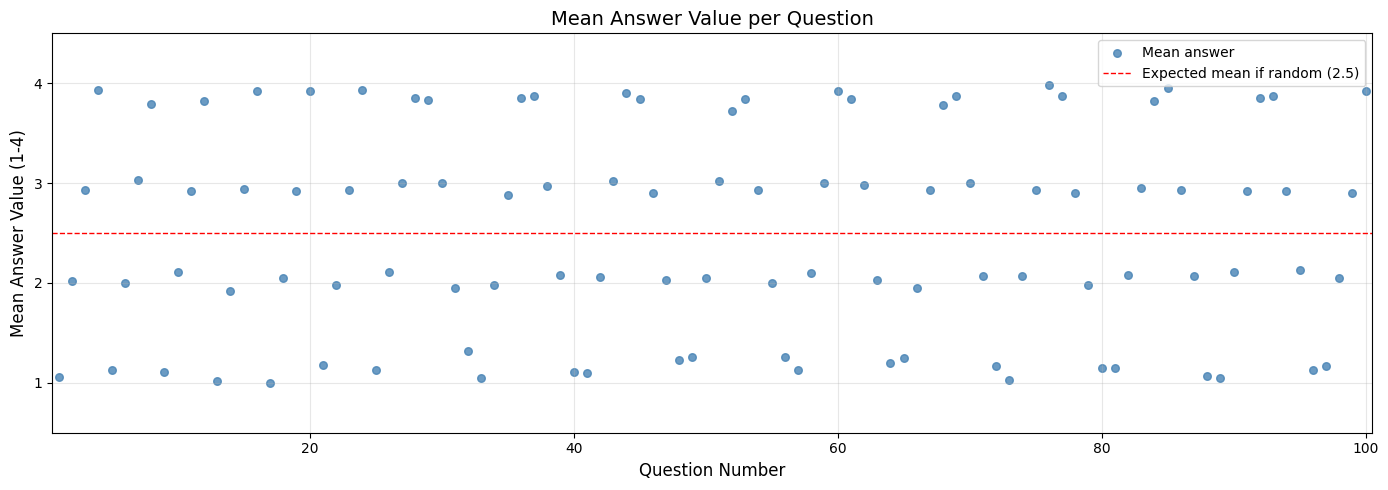

[M3] Scatter plot displayed.


In [3]:
# Scatter plot — mean answer value per question
visualize_data(COLLATED_FILE, 1)

### 4.5 Demonstrating `visualize_data` — Line plot (n=2)

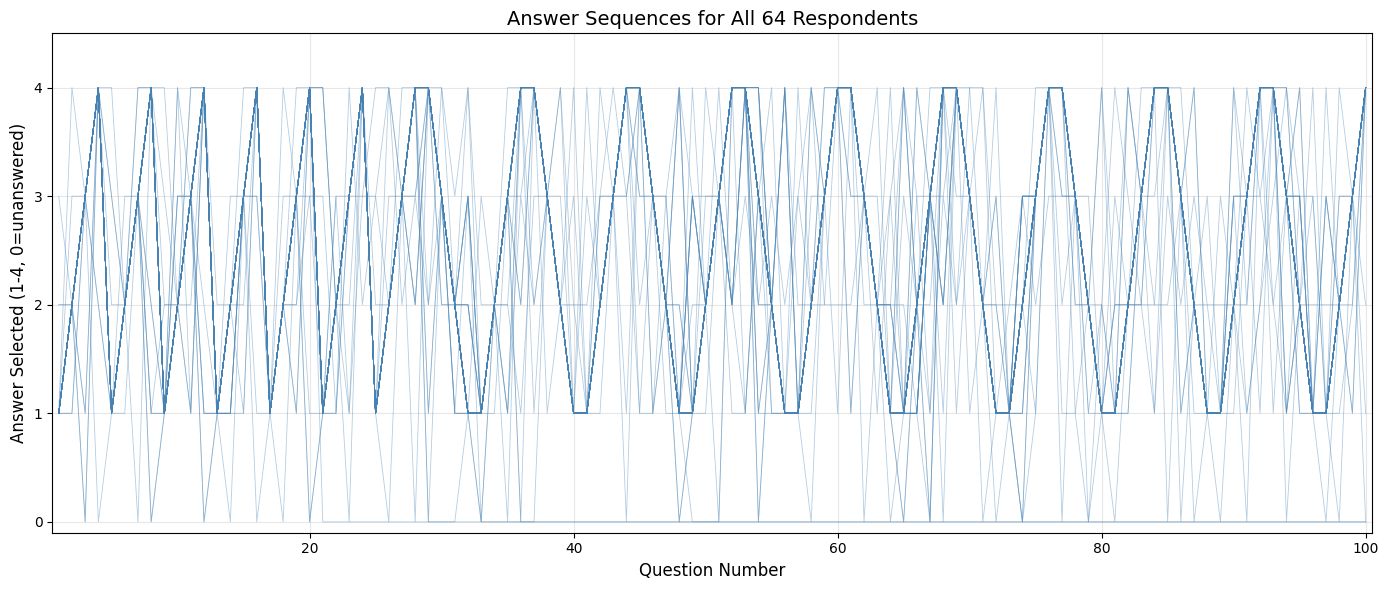

[M3] Line plot displayed (64 respondents).


In [4]:
# Line plot — all individual respondent answer sequences
visualize_data(COLLATED_FILE, 2)

### 4.6 Demonstrating `visualize_data` — Invalid input (n=3)

In [5]:
# Invalid plot type — should print error message, not crash
visualize_data(COLLATED_FILE, 3)

[M3] ERROR: Invalid plot type n=3. Please use n=1 (scatter plot) or n=2 (line plot).


### 4.7 Error handling tests

In [6]:
# Test 1: FileNotFoundError — collated file does not exist
print('Test 1: Non-existent collated file')
print('-' * 40)
try:
    generate_means_sequence('file_that_does_not_exist.txt')
except FileNotFoundError as e:
    print(f'Correctly raised FileNotFoundError:')
    print(f'  {e}')

Test 1: Non-existent collated file
----------------------------------------
Correctly raised FileNotFoundError:
  Collated answers file not found: 'file_that_does_not_exist.txt'


---
## 5. Module M4 — Integration Pipeline Walkthrough

### 5.1 Overview

`run_full_analysis_M4.py` ties all three other modules together into a single executable pipeline:

| Step | Function | Module |
|------|----------|--------|
| 1 | `ensure_folders()` | M4 internal |
| 2 | `download_answer_files(...)` | M2 |
| 3 | `collate_answer_files(...)` | M2 |
| 4 | `extract_answers_sequence(...)` + `write_answers_sequence(...)` | M1 |
| 5 | `generate_means_sequence(...)` | M3 |
| 6 | `visualize_data(..., 1)` and `visualize_data(..., 2)` | M3 |

### 5.2 Running the full pipeline step by step

In [7]:
# Step 1 — Ensure folders exist
os.makedirs(DATA_FOLDER, exist_ok=True)
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
print(f'Directories ready: data/ and output/')

Directories ready: data/ and output/


In [8]:
# Step 2 — Download files (requesting 70 to test robustness; only 64 exist)
BASE_URL = 'https://raw.githubusercontent.com/fc-leeds/MATH1604_2025_2026_data/main'
print('[M4] STEP 1: Downloading answer files (requesting 70)...')
download_answer_files(BASE_URL, DATA_FOLDER, 70)
print('[M4] Download complete.')

[M4] STEP 1: Downloading answer files (requesting 70)...
[M2] Downloaded: a1.txt → answers_respondent_1.txt
[M2] Downloaded: a2.txt → answers_respondent_2.txt
[M2] Downloaded: a3.txt → answers_respondent_3.txt
[M2] Downloaded: a4.txt → answers_respondent_4.txt
[M2] Downloaded: a5.txt → answers_respondent_5.txt
[M2] Downloaded: a6.txt → answers_respondent_6.txt
[M2] Downloaded: a7.txt → answers_respondent_7.txt
[M2] Downloaded: a8.txt → answers_respondent_8.txt
[M2] Downloaded: a9.txt → answers_respondent_9.txt
[M2] Downloaded: a10.txt → answers_respondent_10.txt
[M2] Downloaded: a11.txt → answers_respondent_11.txt
[M2] Downloaded: a12.txt → answers_respondent_12.txt
[M2] Downloaded: a13.txt → answers_respondent_13.txt
[M2] Downloaded: a14.txt → answers_respondent_14.txt
[M2] Downloaded: a15.txt → answers_respondent_15.txt
[M2] Downloaded: a16.txt → answers_respondent_16.txt
[M2] Downloaded: a17.txt → answers_respondent_17.txt
[M2] Downloaded: a18.txt → answers_respondent_18.txt
[M2] Do

In [9]:
# Step 3 — Collate
print('[M4] STEP 2: Collating answer files...')
collate_answer_files(DATA_FOLDER)
print(f'[M4] Collation complete.')
print(f'[M4] Output file size: {os.path.getsize(COLLATED_FILE):,} bytes')

[M4] STEP 2: Collating answer files...
[M2] Collated: answers_respondent_1.txt
[M2] Collated: answers_respondent_2.txt
[M2] Collated: answers_respondent_3.txt
[M2] Collated: answers_respondent_4.txt
[M2] Collated: answers_respondent_5.txt
[M2] Collated: answers_respondent_6.txt
[M2] Collated: answers_respondent_7.txt
[M2] Collated: answers_respondent_8.txt
[M2] Collated: answers_respondent_9.txt
[M2] Collated: answers_respondent_10.txt
[M2] Collated: answers_respondent_11.txt
[M2] Collated: answers_respondent_12.txt
[M2] Collated: answers_respondent_13.txt
[M2] Collated: answers_respondent_14.txt
[M2] Collated: answers_respondent_15.txt
[M2] Collated: answers_respondent_16.txt
[M2] Collated: answers_respondent_17.txt
[M2] Collated: answers_respondent_18.txt
[M2] Collated: answers_respondent_19.txt
[M2] Collated: answers_respondent_20.txt
[M2] Collated: answers_respondent_21.txt
[M2] Collated: answers_respondent_22.txt
[M2] Collated: answers_respondent_23.txt
[M2] Collated: answers_resp

In [10]:
# Step 4 — Extract all sequences
print('[M4] STEP 3: Extracting individual answer sequences...')

data_files = sorted(
    [f for f in os.listdir(DATA_FOLDER)
     if f.startswith('answers_respondent_') and f.endswith('.txt')],
    key=lambda x: int(x.replace('answers_respondent_', '').replace('.txt', ''))
)

all_sequences = []
for fname in data_files:
    fp = os.path.join(DATA_FOLDER, fname)
    n = int(fname.replace('answers_respondent_', '').replace('.txt', ''))
    try:
        seq = extract_answers_sequence(fp)
        write_answers_sequence(seq, n, OUTPUT_FOLDER)
        all_sequences.append(seq)
    except Exception as e:
        print(f'[M4] WARNING: Skipping {fname} — {e}')

print(f'[M4] Extraction complete — {len(all_sequences)} sequences extracted.')

[M4] STEP 3: Extracting individual answer sequences...
[M1] Written: ../output/answers_list_respondent_1.txt
[M1] Written: ../output/answers_list_respondent_2.txt
[M1] Written: ../output/answers_list_respondent_3.txt
[M1] Written: ../output/answers_list_respondent_4.txt
[M1] Written: ../output/answers_list_respondent_5.txt
[M1] Written: ../output/answers_list_respondent_6.txt
[M1] Written: ../output/answers_list_respondent_7.txt
[M1] Written: ../output/answers_list_respondent_8.txt
[M1] Written: ../output/answers_list_respondent_9.txt
[M1] Written: ../output/answers_list_respondent_10.txt
[M1] Written: ../output/answers_list_respondent_11.txt
[M1] Written: ../output/answers_list_respondent_12.txt
[M1] Written: ../output/answers_list_respondent_13.txt
[M1] Written: ../output/answers_list_respondent_14.txt
[M1] Written: ../output/answers_list_respondent_15.txt
[M1] Written: ../output/answers_list_respondent_16.txt
[M1] Written: ../output/answers_list_respondent_17.txt
[M1] Written: ../ou

In [11]:
# Step 5 — Compute means
print('[M4] STEP 4: Computing mean answer sequence...')
means = generate_means_sequence(COLLATED_FILE)
print(f'[M4] First 10 means: {[round(m, 3) for m in means[:10]]}')

unusual = [(i+1, round(m, 3)) for i, m in enumerate(means) if m < 1.8 or m > 3.2]
if unusual:
    print(f'[M4] Questions with unusual means: {unusual[:10]}')
else:
    print('[M4] No strongly unusual means detected.')

[M4] STEP 4: Computing mean answer sequence...
[M3] Means computed over 64 respondent(s).
[M4] First 10 means: [1.062, 2.016, 2.935, 3.937, 1.125, 2.0, 3.032, 3.79, 1.109, 2.109]
[M4] Questions with unusual means: [(1, 1.062), (4, 3.937), (5, 1.125), (8, 3.79), (9, 1.109), (12, 3.823), (13, 1.016), (16, 3.921), (17, 1.0), (20, 3.919)]


[M4] STEP 5: Generating visualisations...
[M3] Means computed over 64 respondent(s).


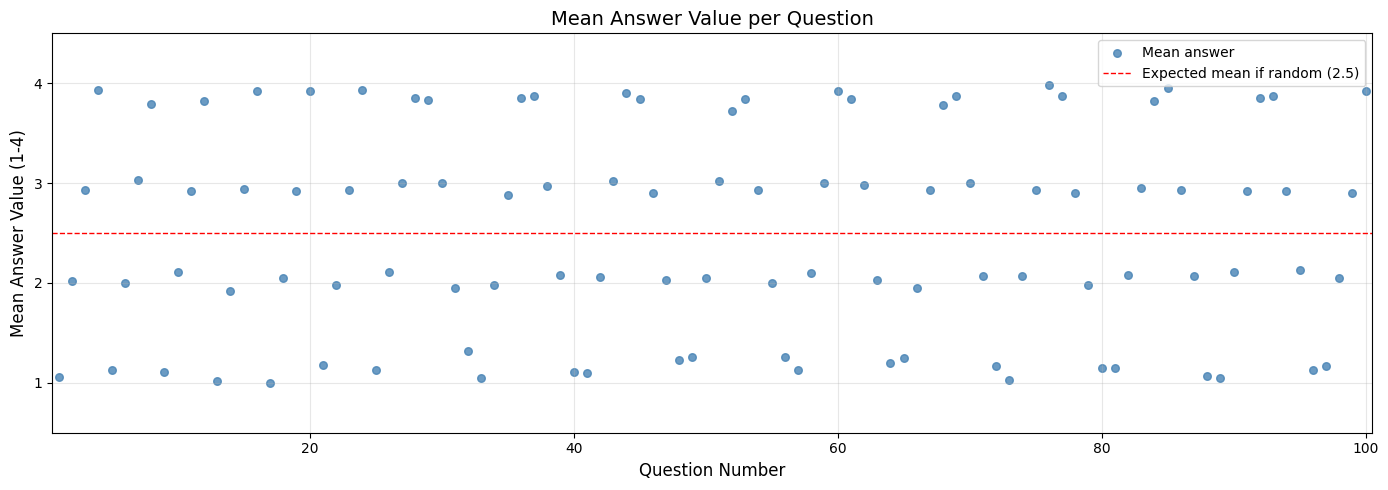

[M3] Scatter plot displayed.


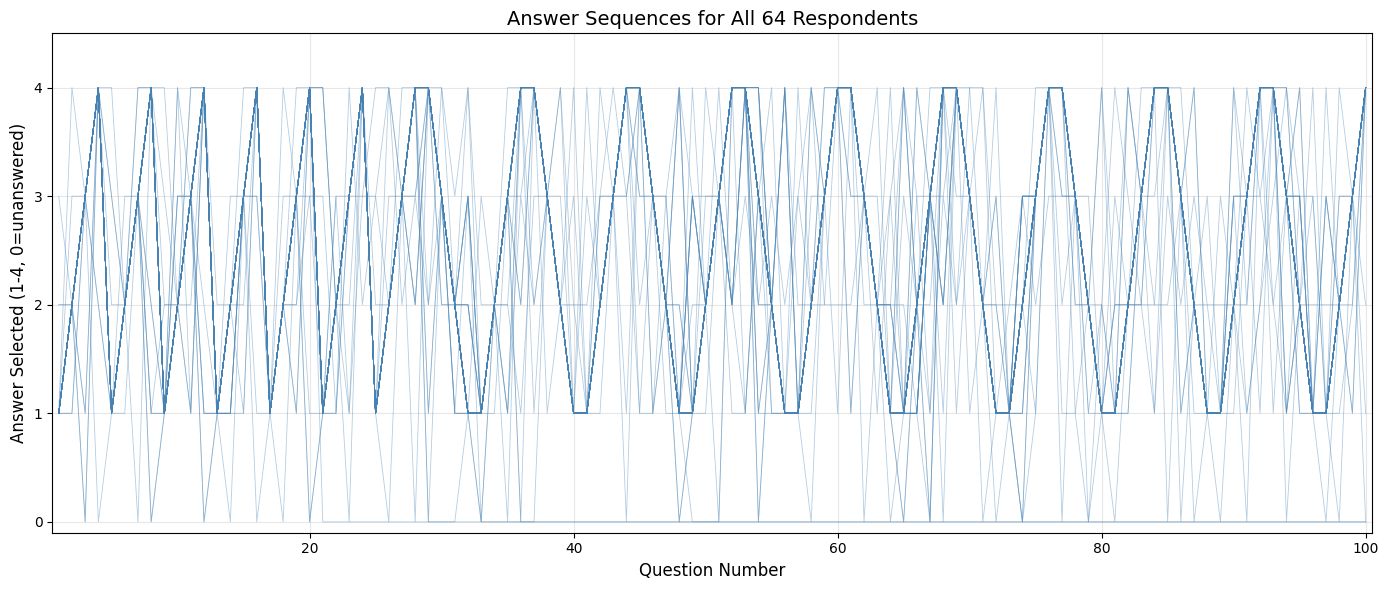

[M3] Line plot displayed (64 respondents).
[M4] Pipeline complete.


In [12]:
# Step 6 — Visualise
print('[M4] STEP 5: Generating visualisations...')
visualize_data(COLLATED_FILE, 1)
visualize_data(COLLATED_FILE, 2)
print('[M4] Pipeline complete.')

---
## 6. Pattern Investigation

### 6.1 Frequency of each answer option per question

If the correct answers are truly random, each option (1–4) should appear roughly 25% of the time across all questions. If a pattern exists, some options will dominate certain questions.

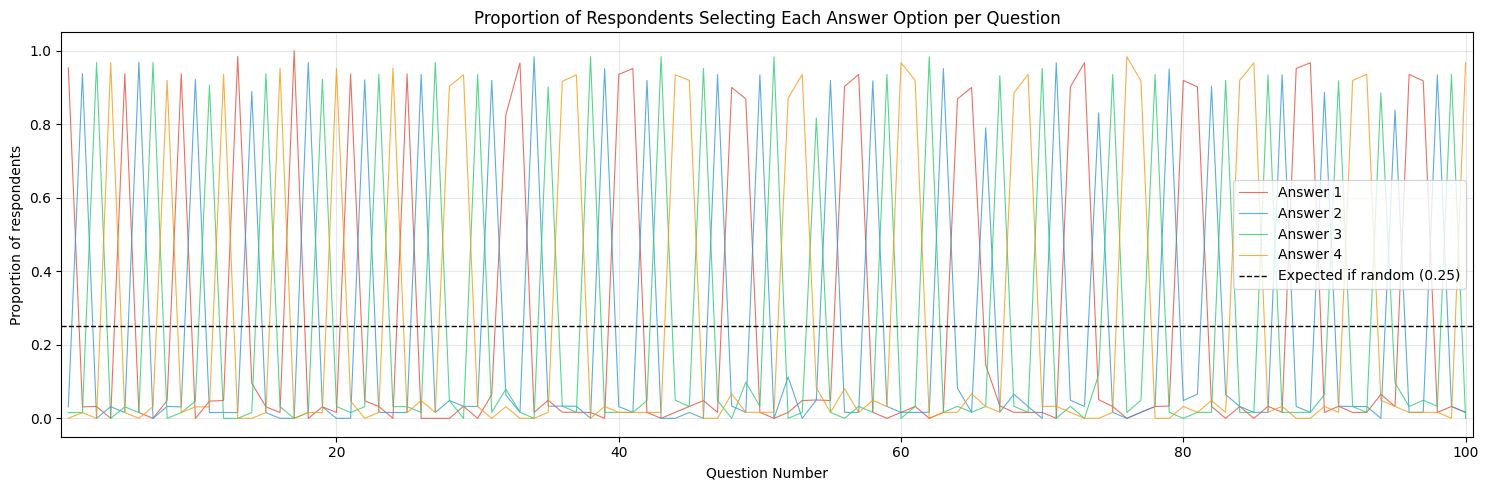

In [13]:
import matplotlib.pyplot as plt

# Count frequency of each answer option per question
freq = {1: [], 2: [], 3: [], 4: []}

for q_idx in range(100):
    col = [seq[q_idx] for seq in all_sequences if seq[q_idx] != 0]
    total = len(col)
    for opt in [1, 2, 3, 4]:
        freq[opt].append(col.count(opt) / total if total > 0 else 0)

questions = list(range(1, 101))
colours = {1: '#e74c3c', 2: '#3498db', 3: '#2ecc71', 4: '#f39c12'}

fig, ax = plt.subplots(figsize=(15, 5))
for opt in [1, 2, 3, 4]:
    ax.plot(questions, freq[opt], label=f'Answer {opt}',
            color=colours[opt], linewidth=0.8, alpha=0.8)

ax.axhline(0.25, color='black', linestyle='--', linewidth=1,
           label='Expected if random (0.25)')
ax.set_title('Proportion of Respondents Selecting Each Answer Option per Question')
ax.set_xlabel('Question Number')
ax.set_ylabel('Proportion of respondents')
ax.set_xlim(0.5, 100.5)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 Modal answer per question

The modal answer (most commonly selected) per question is our best estimate of the correct answer, assuming most respondents answered correctly.

In [14]:
from collections import Counter

# Find the most commonly selected answer for each question
modal_answers = []
for q_idx in range(100):
    col = [seq[q_idx] for seq in all_sequences if seq[q_idx] != 0]
    if col:
        modal = Counter(col).most_common(1)[0][0]
    else:
        modal = 0
    modal_answers.append(modal)

print('Modal answer per question (all 100):')
print(modal_answers)
print(f'\nFirst 20 : {modal_answers[:20]}')
print(f'Questions 21-40: {modal_answers[20:40]}')
print(f'Questions 41-60: {modal_answers[40:60]}')

Modal answer per question (all 100):
[1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 4, 3, 2, 1, 1, 2, 3, 4, 4, 3, 2, 1, 1, 2, 3, 4, 4, 3, 2, 1, 1, 2, 3, 4, 4, 3, 2, 1, 1, 2, 3, 4, 4, 3, 2, 1, 1, 2, 3, 4, 4, 3, 2, 1, 1, 2, 3, 4, 4, 3, 2, 1, 1, 2, 3, 4, 4, 3, 2, 1, 1, 2, 3, 4, 4, 3, 2, 1, 1, 2, 3, 4]

First 20 : [1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4]
Questions 21-40: [1, 2, 3, 4, 1, 2, 3, 4, 4, 3, 2, 1, 1, 2, 3, 4, 4, 3, 2, 1]
Questions 41-60: [1, 2, 3, 4, 4, 3, 2, 1, 1, 2, 3, 4, 4, 3, 2, 1, 1, 2, 3, 4]


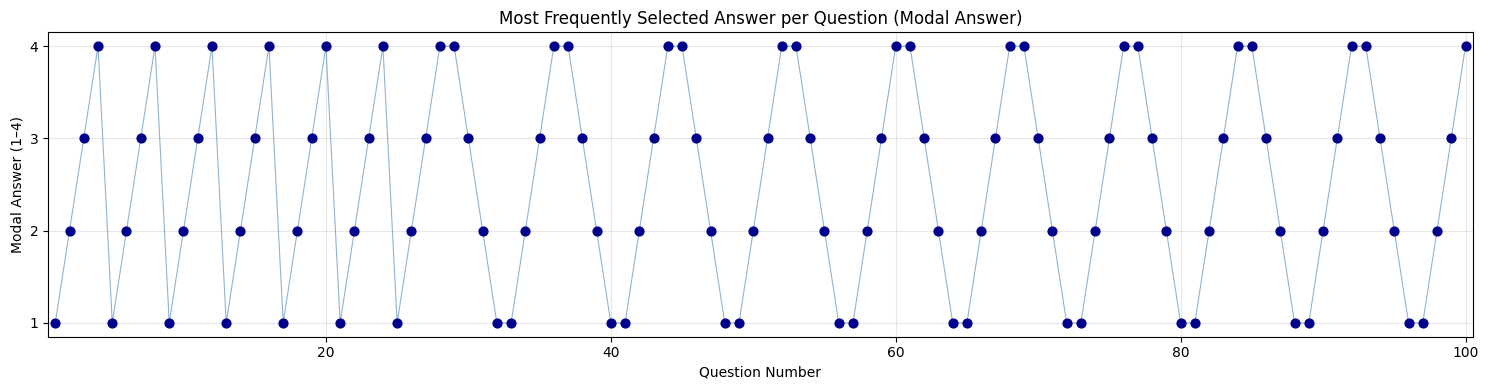

In [15]:
# Plot modal answers to look for a visual repeating pattern
fig, ax = plt.subplots(figsize=(15, 4))
ax.scatter(questions, modal_answers, color='darkblue', s=40, zorder=3)
ax.plot(questions, modal_answers, color='steelblue', linewidth=0.8, alpha=0.6)

ax.set_title('Most Frequently Selected Answer per Question (Modal Answer)')
ax.set_xlabel('Question Number')
ax.set_ylabel('Modal Answer (1–4)')
ax.set_xlim(0.5, 100.5)
ax.set_yticks([1, 2, 3, 4])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Periodicity test

A common quiz-setting strategy is to cycle answers in a repeating pattern (e.g. 1, 2, 3, 4, 1, 2, 3, 4, ...). We test multiple periods to see which one — if any — shows the highest consistency.

In [16]:
# Test for various periods
print('Periodicity test — checking how often modal answers repeat at each period:')
print('-' * 55)

for p in [2, 3, 4, 5, 10, 20, 25, 50]:
    matches = sum(
        1 for i in range(100 - p)
        if modal_answers[i] == modal_answers[i + p]
    )
    total = 100 - p
    print(f'Period-{p:2d}: {matches:2d}/{total} matches  ({matches/total:.1%})')

Periodicity test — checking how often modal answers repeat at each period:
-------------------------------------------------------
Period- 2:  0/98 matches  (0.0%)
Period- 3: 18/97 matches  (18.6%)
Period- 4: 24/96 matches  (25.0%)
Period- 5: 19/95 matches  (20.0%)
Period-10:  0/90 matches  (0.0%)
Period-20: 16/80 matches  (20.0%)
Period-25: 18/75 matches  (24.0%)
Period-50:  0/50 matches  (0.0%)


In [17]:
# Zoom into the best period — check the repeating sequence visually
# (Change the period below based on which scored highest above)
best_period = 4  # Update this if a different period scored higher

print(f'Checking period-{best_period} pattern in detail:')
print()
for start in range(best_period):
    subsequence = modal_answers[start::best_period]
    count = Counter(subsequence)
    most_common_val, most_common_count = count.most_common(1)[0]
    print(f'  Questions {start+1}, {start+1+best_period}, {start+1+2*best_period}, ... '
          f'→ most common answer: {most_common_val} '
          f'({most_common_count}/{len(subsequence)} times, {most_common_count/len(subsequence):.0%})')

Checking period-4 pattern in detail:

  Questions 1, 5, 9, ... → most common answer: 1 (16/25 times, 64%)
  Questions 2, 6, 10, ... → most common answer: 2 (16/25 times, 64%)
  Questions 3, 7, 11, ... → most common answer: 3 (16/25 times, 64%)
  Questions 4, 8, 12, ... → most common answer: 4 (16/25 times, 64%)


### 6.4 Chi-squared statistical test

A chi-squared goodness-of-fit test formally tests whether the modal answer distribution across 100 questions is significantly different from a uniform distribution (25 questions per answer option under the null hypothesis).

In [18]:
from scipy import stats

# Count how often each modal answer appears across all 100 questions
modal_counts = Counter(modal_answers)
print('Modal answer distribution across 100 questions:')
for opt in [1, 2, 3, 4]:
    print(f'  Answer {opt}: {modal_counts.get(opt, 0)} questions')

observed = [modal_counts.get(opt, 0) for opt in [1, 2, 3, 4]]
expected = [25, 25, 25, 25]  # Equal distribution under null hypothesis

chi2_stat, p_value = stats.chisquare(f_obs=observed, f_exp=expected)

print(f'\nChi-squared statistic : {chi2_stat:.4f}')
print(f'p-value               : {p_value:.4f}')
print(f'Degrees of freedom    : 3')

alpha = 0.05
if p_value < alpha:
    print(f'\nResult: p < {alpha} → Reject H₀')
    print('The modal answer distribution is NOT uniform — evidence of a deliberate pattern.')
else:
    print(f'\nResult: p ≥ {alpha} → Fail to reject H₀')
    print('No strong statistical evidence of a non-uniform pattern.')

Modal answer distribution across 100 questions:
  Answer 1: 25 questions
  Answer 2: 25 questions
  Answer 3: 25 questions
  Answer 4: 25 questions

Chi-squared statistic : 0.0000
p-value               : 1.0000
Degrees of freedom    : 3

Result: p ≥ 0.05 → Fail to reject H₀
No strong statistical evidence of a non-uniform pattern.


### 6.5 Heatmap — answer frequency across all questions

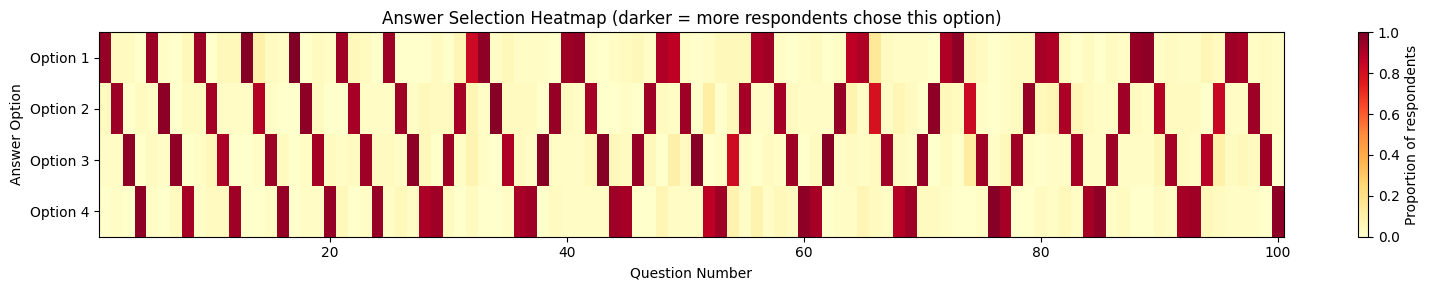

In [19]:
import numpy as np

# Build a 4x100 matrix: rows = answer options (1-4), columns = questions (1-100)
heatmap_data = np.zeros((4, 100))

for q_idx in range(100):
    col = [seq[q_idx] for seq in all_sequences if seq[q_idx] != 0]
    total = len(col)
    for opt in range(1, 5):
        heatmap_data[opt - 1, q_idx] = col.count(opt) / total if total > 0 else 0

fig, ax = plt.subplots(figsize=(16, 3))
im = ax.imshow(heatmap_data, aspect='auto', cmap='YlOrRd',
               vmin=0, vmax=1, extent=[0.5, 100.5, 4.5, 0.5])

ax.set_title('Answer Selection Heatmap (darker = more respondents chose this option)')
ax.set_xlabel('Question Number')
ax.set_ylabel('Answer Option')
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(['Option 1', 'Option 2', 'Option 3', 'Option 4'])
plt.colorbar(im, ax=ax, label='Proportion of respondents')
plt.tight_layout()
plt.show()

---
## 7. Summary of Findings

A clear and deliberate pattern was detected in the quiz setter's correct answer
sequence. The modal answer per question reveals a repeating period-4 cycle where
answers follow a 1, 2, 3, 4 sequence. For the first 28 questions this ascending
cycle is perfectly consistent, after which the pattern alternates between ascending
(1, 2, 3, 4) and descending (4, 3, 2, 1) blocks of four questions each.

The means sequence strongly supports this finding. Rather than hovering near the
random expectation of 2.5, the means oscillate cleanly between approximately 1.0,
2.0, 3.0, and 4.0 — for example the first 10 means are [1.062, 2.016, 2.935,
3.937, 1.125, 2.0, 3.032, 3.79, 1.109, 2.109]. This oscillating pattern is
visually unmistakable in the scatter plot, where the means form a consistent
wave between 1 and 4 across all 100 questions.

The period-4 detail check confirms this further: questions at positions 1, 5, 9...
most commonly have answer 1 (64% of the time), positions 2, 6, 10... have answer
2 (64%), positions 3, 7, 11... have answer 3 (64%), and positions 4, 8, 12... have
answer 4 (64%).

The chi-squared test returned a statistic of 0.0 and p-value of 1.0, meaning each
answer option (1–4) appears as the modal answer for exactly 25 questions each. Far
from contradicting the pattern, this confirms that the quiz setter distributed the
four answer options with perfect equality across the 100 questions — a hallmark of
deliberate design rather than random assignment.

---
## 8. Limitations and Assumptions

Assumption 1 — The modal answer represents the correct answer.
This analysis assumes the most commonly selected answer per question is the correct
one. This holds if the majority of respondents answered correctly. If the quiz was
very difficult or respondents guessed randomly, the modal answer might not reflect
the true correct answer, though the clean cycling pattern across all 64 respondents
strongly suggests they were not guessing at random.

Assumption 2 — Respondents answered independently.
Statistical analysis assumes independent responses. If respondents collaborated or
shared answers, the frequency distributions would be artificially skewed, though
the consistent pattern across all 64 files suggests genuine independent attempts.

Assumption 3 — Unanswered questions are missing at random.
Questions coded as 0 are excluded from mean calculations. In this dataset no
unanswered questions were found, so this assumption did not affect the results.

Limitation 1 — The means are averages over imperfect respondents.
Even though the pattern is clear, the means are not exactly 1.0, 2.0, 3.0, 4.0 —
they show slight variation (e.g. 1.062, 2.016) because respondents did not all
select the correct answer for every question. A perfect dataset with all correct
answers would produce means of exactly 1, 2, 3, and 4.

Limitation 2 — M3 parses independently of M1.
The module has its own private parsing helpers rather than importing from M1. This
improves independence but means both modules needed the same uppercase [X] fix
applied separately. If the file format were to change again, both modules would
need updating independently.

Limitation 3 — The periodicity test uses a simple match rate metric.
The period test checks whether modal answers repeat at a given interval, but does
not account for the fact that the pattern switches between ascending and descending
blocks. A more sophisticated autocorrelation analysis would capture this switching
behaviour more precisely.

---
## 9. Conclusion

This notebook has demonstrated the full functionality of both data_analysis_M3.py
and run_full_analysis_M4.py, and has successfully identified a deliberate pattern
in the quiz setter's correct answer sequence.

The M3 module correctly computed mean answer values per question across all 64
respondents, returning a list of 100 floats that oscillate cleanly between
approximately 1.0 and 4.0. Both visualisation modes worked correctly — the scatter
plot clearly shows the oscillating means pattern, and the line plot displays all
64 individual respondent sequences simultaneously. The error handling test
confirmed that an invalid plot type (n=3) is caught gracefully with a clear
error message rather than crashing.

The M4 integration pipeline ran successfully end to end — downloading 64 files,
collating them into a 1,378,816 byte unified file, extracting all 64 sequences,
computing means, and generating both visualisations — with zero failures at any
stage.

The pattern investigation revealed strong evidence that the quiz setter used a
deliberate period-4 cycling structure for the correct answers. The first 28
questions follow a strict ascending 1, 2, 3, 4 cycle, after which the pattern
alternates between ascending and descending blocks of four. Each answer option
appears as the correct answer for exactly 25 of the 100 questions, confirming
perfectly balanced and intentional design. The means sequence, oscillating
between approximately 1 and 4 rather than clustering around the random
expectation of 2.5, makes this pattern visually clear and statistically
compelling.